In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_df = pd.read_csv("./dataset/train.csv")
sales_df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [4]:
sales_df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [5]:
sales_df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


##### As minimum of Product_Category is 1, so we can treat missing values in Product_Category as 0

In [6]:
# sales_df['Product_Category_2'] = sales_df['Product_Category_2'].fillna(0)
# sales_df['Product_Category_3'] = sales_df['Product_Category_3'].fillna(0)

In [7]:
sales_df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

##### There is no such benefit of pretending Product_Category_2 and Product_Category_3 to be float; this consumes a lot of memory, so it is better to convert them into int64

In [8]:
# sales_df['Product_Category_2'] = sales_df['Product_Category_2'].astype('int64')
# sales_df['Product_Category_3'] = sales_df['Product_Category_3'].astype('int64')

In [9]:
sales_df.duplicated().sum()

np.int64(0)

In [10]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


### Exploratory Data Analysis

###### Univariate Analysis

<Axes: xlabel='Age'>

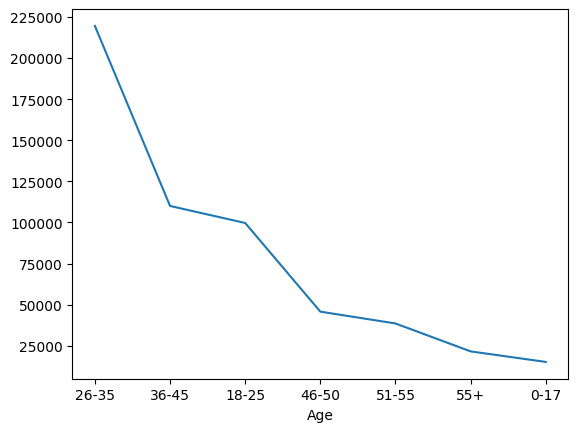

In [11]:
sales_df['Age'].value_counts().plot(kind='line')

<Axes: xlabel='City_Category'>

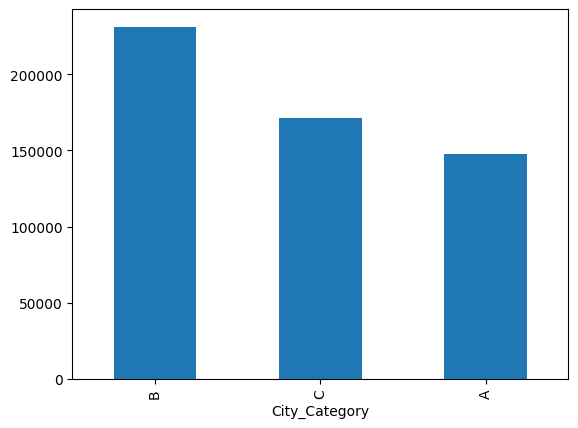

In [12]:
sales_df['City_Category'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

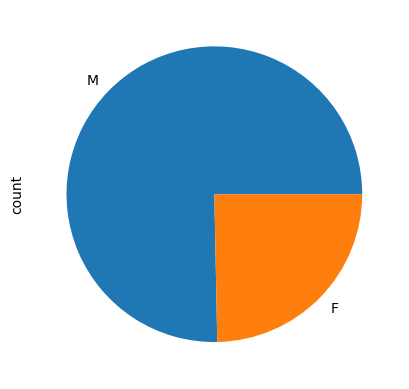

In [13]:
sales_df['Gender'].value_counts().plot(kind='pie')

{'whiskers': [<matplotlib.lines.Line2D at 0x2874a884cd0>,
 'caps': [<matplotlib.lines.Line2D at 0x2874a884f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x2874a884b90>],
 'medians': [<matplotlib.lines.Line2D at 0x2874a8851d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2874a885310>],
 'means': []}

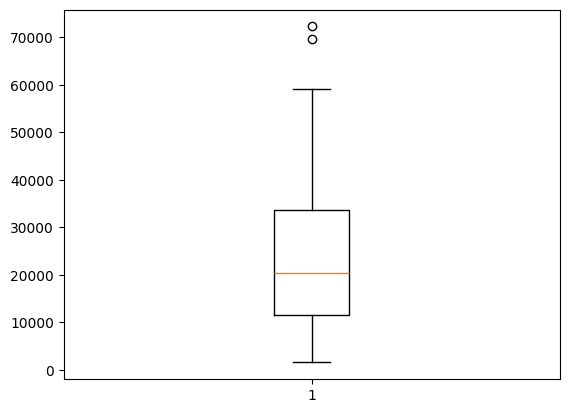

In [14]:
plt.boxplot(sales_df['Occupation'].value_counts())

([<matplotlib.patches.Wedge at 0x2874a8f8b90>,
 [Text(-0.3080416465273359, 1.0559878522050943, ''),
  Text(0.30804211649538404, -1.0559877151108552, '')])

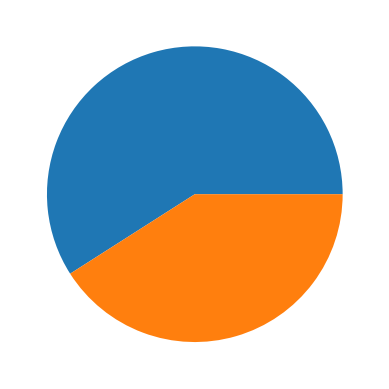

In [15]:
plt.pie(sales_df["Marital_Status"].value_counts())

{'whiskers': [<matplotlib.lines.Line2D at 0x2874a938550>,
 'caps': [<matplotlib.lines.Line2D at 0x2874a9387d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2874a938410>],
 'medians': [<matplotlib.lines.Line2D at 0x2874a938a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2874a938b90>],
 'means': []}

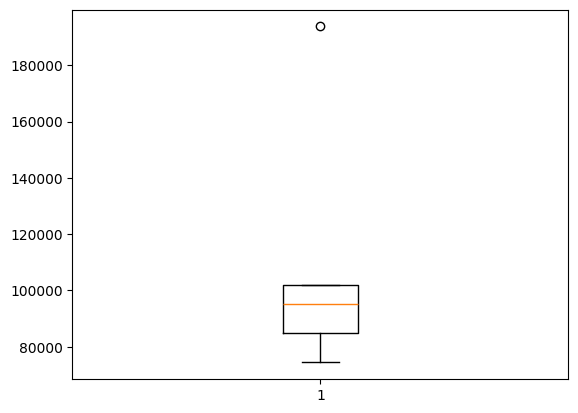

In [16]:
plt.boxplot(sales_df['Stay_In_Current_City_Years'].value_counts())

##### Bi-Variate Analysis / Multi Variate Analysis

<Axes: xlabel='Gender', ylabel='Purchase'>

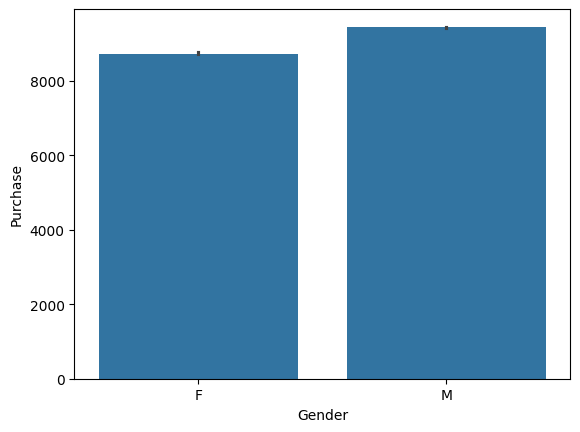

In [17]:
sns.barplot(y="Purchase", x="Gender", data=sales_df)

<Axes: xlabel='Age', ylabel='Purchase'>

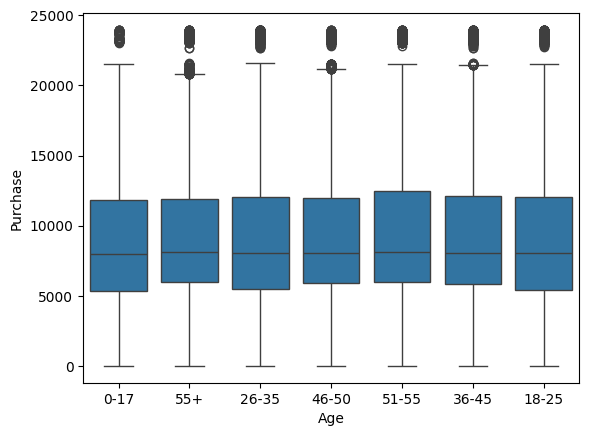

In [18]:
sns.boxplot(y="Purchase", x="Age", data=sales_df)

<Axes: xlabel='Occupation', ylabel='Purchase'>

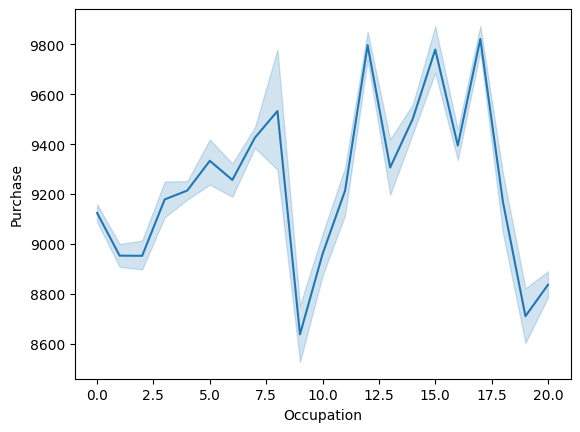

In [19]:
sns.lineplot(y="Purchase", x="Occupation", data=sales_df)

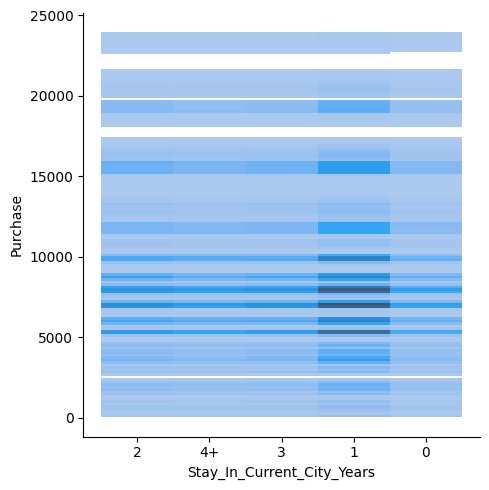

In [20]:
sns.displot(y="Purchase", x="Stay_In_Current_City_Years", data=sales_df)

<Axes: xlabel='City_Category', ylabel='Purchase'>

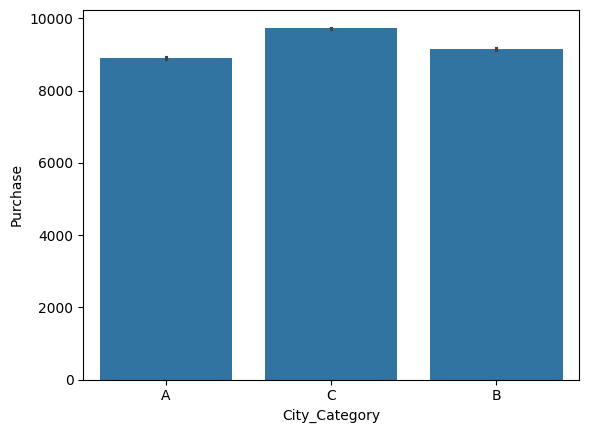

In [21]:
sns.barplot(y=sales_df["Purchase"], x=sales_df["City_Category"])

<Axes: xlabel='Gender', ylabel='Purchase'>

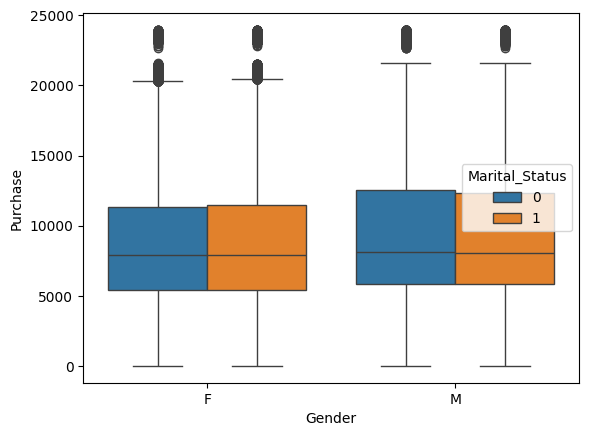

In [22]:
sns.boxplot(x="Gender", y="Purchase", data=sales_df, hue="Marital_Status")

<Axes: xlabel='Age', ylabel='Purchase'>

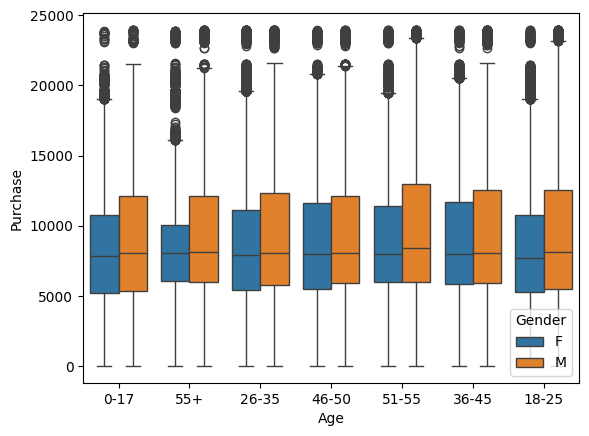

In [23]:
sns.boxplot(x="Age", y="Purchase", data=sales_df, hue="Gender")

In [ ]:
sns.lineplot(x="Occupation", y="Purchase", data=sales_df, hue="City_Category")

In [ ]:
sns.barplot(x="Stay_In_Current_City_Years", y="Purchase", data=sales_df, hue="City_Category")

In [ ]:
sns.scatterplot(x="Product_Category_2", y="Product_Category_1", data=sales_df, hue="Product_Category_3")

In [ ]:
sales_df.sample(5)

In [ ]:
sales_df.info()

In [ ]:
sales_df.drop("User_ID", axis=1, inplace=True)
sales_df.drop("Product_ID", axis=1, inplace=True)

#### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(sales_df.drop("Purchase", axis=1), sales_df["Purchase"], test_size=0.2)

X_train.shape, X_test.shape